# Hotel Booking Cancellation Analysis

## Project Overview

This project analyzes hotel booking data to identify the main patterns associated with booking cancellations. The analysis focuses on market segments, booking lead time, and deposit type to determine which bookings carry the highest cancellation risk.

## Business Problem

Hotel cancellations can reduce occupancy predictability and create potential revenue loss. Management wants to understand which types of bookings are most likely to be canceled and what operational actions could reduce cancellation risk.

## Business Questions

1. What is the overall booking cancellation rate?
2. Which market segments have the highest cancellation volume and rate?
3. Are longer booking lead times associated with higher cancellation rates?
4. Does deposit type appear to be associated with cancellation?
5. Which bookings should management prioritize for confirmation and follow-up?

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from google.colab import files
import os

pd.set_option('display.max_columns', None)

df = pd.read_csv('data/hotel_bookings.csv')

os.makedirs('images', exist_ok=True)

print(f'Dataset shape: {df.shape}')

Saving hotel_bookings.csv to hotel_bookings (3).csv
Loaded file: hotel_bookings (3).csv
Dataset shape: (119390, 32)


**Understanding the dataset**

In [68]:
display(df.dtypes)
df.info()
display(df.describe())
display(df.head())

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 42 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  object        
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  object        
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119386 non-null  float64

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_booked_nights,actual_stays,canceled_stays,total_guests,booking_value,room_changing_room,family_flag,arrival_date
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363,3.427900,2.136192,1.291708,1.968229,357.848208,0.124943,0.078198,2016-08-28 16:39:45.727447808
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-63.800000,0.000000,0.000000,2015-07-01 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000,2.000000,0.000000,0.000000,2.000000,146.000000,0.000000,0.000000,2016-03-13 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000,3.000000,1.000000,0.000000,2.000000,267.000000,0.000000,0.000000,2016-09-06 00:00:00
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000,4.000000,3.000000,2.000000,2.000000,446.250000,0.000000,0.000000,2017-03-18 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000,69.000000,69.000000,56.000000,55.000000,7590.000000,1.000000,1.000000,2017-08-31 00:00:00
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798,2.557439,2.620693,2.278416,0.722400,335.910109,0.330656,0.268483,NaN


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,customer_segment,total_booked_nights,actual_stays,canceled_stays,total_guests,booking_value,room_changing_room,family_flag,lead_time_segments,arrival_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,New Guest,0,0,0,2.0,0.0,0,0,Very Long Lead Time,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,New Guest,0,0,0,2.0,0.0,0,0,Very Long Lead Time,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,New Guest,1,1,0,1.0,75.0,1,0,Short Lead Time,2015-07-01
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,New Guest,1,1,0,1.0,75.0,0,0,Short Lead Time,2015-07-01
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,New Guest,2,2,0,2.0,196.0,0,0,Short Lead Time,2015-07-01


**Data Quality Assessment**

In [ ]:
missing_data = pd.DataFrame({
    'unique_values': df.nunique(),
    'missing_count': df.isna().sum(),
    'missing_pct':df.isna().mean()
}).sort_values('missing_pct', ascending = False)

missing_data

**Feature Engineering**

In [57]:
df['customer_segment'] = np.where(
    df['is_repeated_guest'].eq(1),
    'Repeated Guest',
    'New Guest'
)

df['total_booked_nights'] = (
    df['stays_in_week_nights'] + df['stays_in_weekend_nights']
)


df['actual_stays'] = np.where(
    df['is_canceled'].eq(0),
    df['total_booked_nights'],
    0
)


df['canceled_stays'] = np.where(
    df['is_canceled'].eq(1),
    df['total_booked_nights'],
    0
)


df['total_guests'] = df['adults'] + df['children'] + df['babies']


df['booking_value'] = (
    df['adr'] * df['total_booked_nights']
)


df['room_changing_room'] = np.where(
    df['reserved_room_type'] != df['assigned_room_type'],
    1,
    0
)

df['family_flag'] = np.where(
   (df['children'] != 0) |
    (df['babies'] !=0),
    1,
    0
)

df['lead_time_segments'] = pd.qcut(
    df['lead_time'],
    q= 4,
    labels= ('Short Lead Time' , 'Medium Lead Time', 'Long Lead Time', 'Very Long Lead Time')
)

df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str)
)


**Overall KPIs**

In [55]:
canceled_rate = df['is_canceled'].mean()

family_pct = df['family_flag'].mean()

room_changing_pct = df['room_changing_room'].mean()

lost_room_nights = df['canceled_stays'].sum()

lost_booking_value = df.loc[
    df['is_canceled'].eq(1),
    'booking_value'
].sum()

print(f"Cancelation Percentage : {canceled_rate:.2%}")
print(f"Family Percantege: {family_pct:.2%}")
print(f"Room Changing Percentage: {room_changing_pct:.2%}")
print(f"Total Lost Room Nights: {lost_room_nights}")
print(f"Total Lost Booking Value: {lost_booking_value:.2f}")

Cancelation Percentage : 37.04%
Family Percantege: 7.82%
Room Changing Percentage: 12.49%
Total Lost Room Nights: 154217
Total Lost Booking Value: 4641942.67


In [ ]:
# Segmentation Function

def segment_analysis (df, segment_col):
  summary = (
      df.groupby(segment_col)
      .agg(
          total_reservation = ('hotel','size'),
          cancellation_volume = ('is_canceled','sum'),
          cancellation_rate = ('is_canceled','mean'),
          avg_booking_value = ('booking_value','mean'),
          avg_lead_time = ('lead_time','mean')
      )
      .query('total_reservation > 300')
      .sort_values('cancellation_rate', ascending = False)
      .reset_index()
      .head(10)
  )

  return summary

**Market Segment Analysis**

In [ ]:
# Which market has the highest cancellation volume & rate ?

market_analysis = segment_analysis (df,'market_segment')

market_analysis

,market_segment,total_reservation,cancellation_volume,cancellation_rate,avg_booking_value,avg_lead_time
0,Groups,19811,12097,0.610620,79.479472,186.973096
1,Online TA,56477,20739,0.367211,117.197063,82.998725
2,Offline TA/TO,24219,8311,0.343160,87.354783,135.004459
3,Corporate,5295,992,0.187347,69.358952,22.125590
4,Direct,12606,1934,0.153419,115.445175,49.859115
5,Complementary,743,97,0.130552,2.886366,13.286676


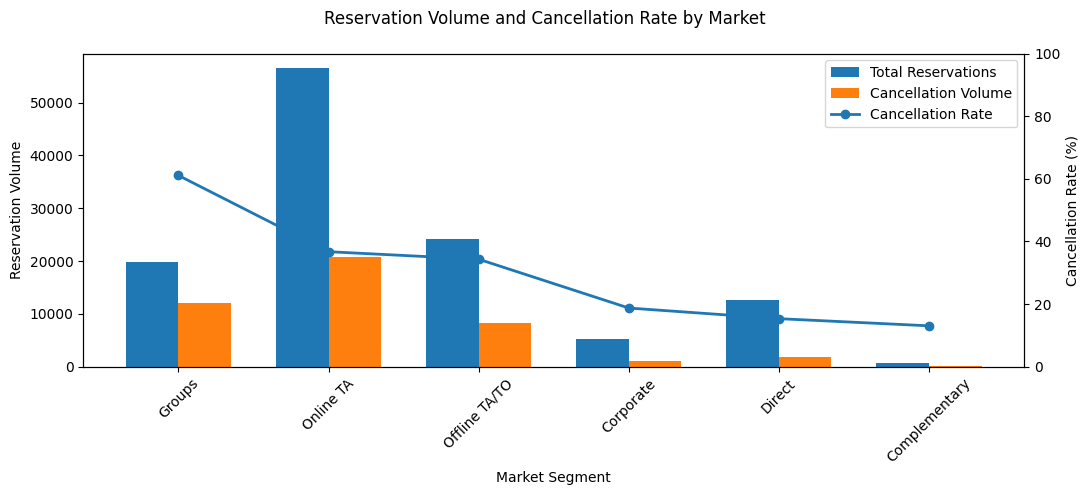

In [72]:
x = np.arange(len(market_analysis['market_segment']))
width = 0.35

fig, ax1 = plt.subplots(figsize=(11, 5))


ax1.bar(
    x - width / 2,
    market_analysis['total_reservation'],
    width,
    label='Total Reservations'
)

ax1.bar(
    x + width / 2,
    market_analysis['cancellation_volume'],
    width,
    label='Cancellation Volume'
)

ax1.set_xlabel('Market Segment')
ax1.set_ylabel('Reservation Volume')
ax1.set_xticks(x)
ax1.set_xticklabels(
    market_analysis['market_segment'],
    rotation=45
)


ax2 = ax1.twinx()

ax2.plot(
    x,
    market_analysis['cancellation_rate'] * 100,
    marker='o',
    linewidth=2,
    label='Cancellation Rate'
)

ax2.set_ylabel('Cancellation Rate (%)')
ax2.set_ylim(0, 100)

fig.suptitle('Reservation Volume and Cancellation Rate by Market')


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper right'
)

plt.tight_layout()
plt.savefig(
    'images/cancellation_by_market.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

**Deposit Type Investigation**

In [ ]:
# Is deposite type ascociate with higher cancelation ?

deposite_type_analysis = segment_analysis (df, 'deposit_type')

deposite_type_analysis

,deposit_type,total_reservation,cancellation_volume,cancellation_rate,avg_booking_value,avg_lead_time
0,Non Refund,14587,14494,0.993624,89.964017,212.908891
1,No Deposit,104641,29694,0.283770,103.525067,88.756615


**Lead Time Investigation**

In [ ]:
# Is lead time ascociate with higher cancelation ?

lead_time_analysis = segment_analysis (df,'lead_time_segments')

/tmp/ipykernel_567/3679026002.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(segment_col)


,lead_time_segments,total_reservation,cancellation_volume,cancellation_rate,avg_booking_value,avg_lead_time
0,Very Long Lead Time,29822,16533,0.554389,96.367200,258.850211
1,Long Lead Time,29669,12632,0.425764,107.969201,110.719168
2,Medium Lead Time,29639,10630,0.358649,107.472297,41.628159
3,Short Lead Time,30260,4429,0.146365,95.672351,5.940119


In [ ]:
# Is canceled reservations has higher lead time ?

df.groupby('is_canceled')['lead_time'].agg(
    count='count',
    mean='mean',
    median='median'
)

,count,mean,median
is_canceled,,,
0,75166,79.984687,45.0
1,44224,144.848815,113.0


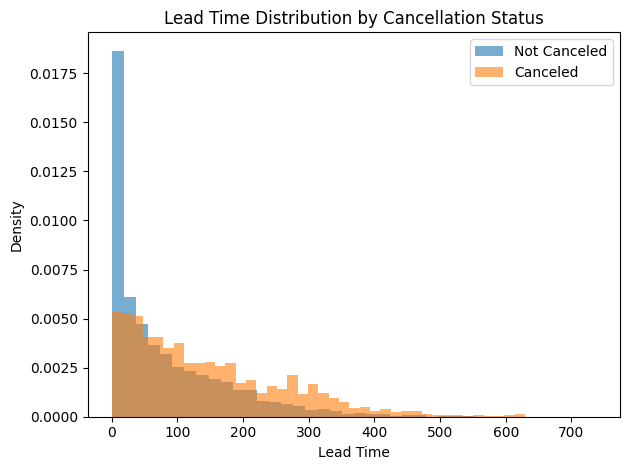

In [75]:
plt.hist(
    df.loc[df['is_canceled'] == 0, 'lead_time'].dropna(),
    bins=40,
    alpha=0.6,
    density=True,
    label='Not Canceled'
)

plt.hist(
    df.loc[df['is_canceled'] == 1, 'lead_time'].dropna(),
    bins=40,
    alpha=0.6,
    density=True,
    label='Canceled'
)

plt.xlabel('Lead Time')
plt.ylabel('Density')
plt.title('Lead Time Distribution by Cancellation Status')
plt.legend()
plt.tight_layout()

plt.savefig(
    'images/Lead_time_distribution_by_cancellation_status.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
df['lead_time_segment'] = pd.cut(
    df['lead_time'],
    bins=[-1, 7, 30, 90, 180, float('inf')],
    labels=['0–7', '8–30', '31–90', '91–180', '180+']
)

lead_time_analysis = (
    df.groupby('lead_time_segment', observed=True)
      .agg(
          total_bookings=('is_canceled', 'size'),
          cancellation_rate=('is_canceled', 'mean')
      )
      .reset_index()
)

lead_time_analysis

,lead_time_segment,total_bookings,cancellation_rate
0,0–7,19746,0.096323
1,8–30,18960,0.278639
2,31–90,29553,0.376984
3,91–180,26439,0.447105
4,180+,24692,0.570104


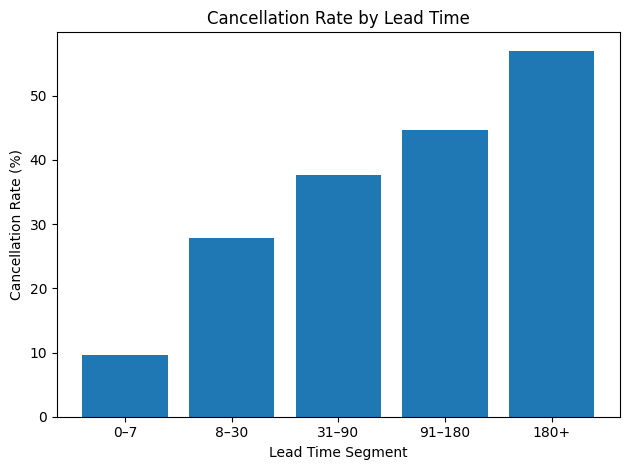

In [76]:
plt.bar(
    lead_time_analysis['lead_time_segment'],
    lead_time_analysis['cancellation_rate'] * 100
)

plt.xlabel('Lead Time Segment')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Lead Time')
plt.tight_layout()

plt.savefig(
    'images/cancellation_by_lead_time.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

**Statistical Validation**

In [51]:
canceled = df.loc[df['is_canceled'].eq(1),'lead_time'].dropna()
not_canceled = df.loc[df['is_canceled'].eq(0), 'lead_time'].dropna()

result = stats.mannwhitneyu(
    canceled,
    not_canceled,
    alternative='two-sided'
)
n1 = len(canceled)
n2 = len(not_canceled)

rank_biserial = (2 * result.statistic) / (n1 * n2) - 1

print(f'Rank-biserial: {rank_biserial:.3f}')
print(f"P-value: {result.pvalue:.5e}")

Rank-biserial: 0.379
P-value: 0.00000e+00


**Key Finding**
*   Overall cancellation rate was 37%.
*   Groups had the highest cancellation rate at 61%.
*   Canceled bookings had a median lead time of 113 days compared with 45 days for non-canceled bookings.
*   Cancellation rate increased consistently from 9.6% for bookings made within seven days to 57% for bookings made more than 180 days in advance.

**Business Interpretation**

Longer lead time is strongly associated with a higher likelihood of cancellation. However, differences between market segments indicate that lead time is not the only factor influencing cancellation.

**Recommendations**

* Use stricter confirmation or reminder policies for bookings with long lead times.
* Prioritize bookings made more than 90 days in advance for reconfirmation.
* Review cancellation and deposit policies for Groups and Online TA bookings.
* Investigate the interaction between market segment and deposit type before changing deposit policy.





